# 00 — Features: TF‑IDF + FinBERT + MacroTone
Ce notebook construit des **features documentaires** à partir de phrases :  
- TF‑IDF (1–2‑grammes) → agrégation par `Doc_ID` → **SVD** (LSA) + scree plot  
- **FinBERT** (optionnel) sur phrases → agrégation doc → histogramme de ton  
- Fusion → **MacroTone_index** = z(SVD1) + z(FinBERT_tone) + tracé temporel

> Ajuste les chemins ci‑dessous (CSV d’entrée et répertoire de sortie).

In [1]:
# Configuration des chemins (à adapter)
IN_CSV = r"C:\Users\Garance Latieule\Projet_ML\Analyzing-ECB\dataset\Final outputs\pre_processed_ECB_conf_final.csv"   # <-- remplace par ton chemin
OUT_DIR = r"C:\Users\Garance Latieule\Projet_ML\Analyzing-ECB\analysis\outputs"                                        # répertoire de sortie
USE_FINBERT = True                                       # mets False si tu n'as pas transformers/Internet
FINBERT_ON_CLEAN = False                                 # True = scorer sur Parsed_Text_clean


In [2]:
# Imports
import os, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

def zscore(x):
    x = pd.Series(x, dtype='float64')
    return (x - x.mean()) / (x.std(ddof=0) + 1e-12)

In [3]:
from pathlib import Path
import pandas as pd

IN = Path(IN_CSV)                       
OUT_DIR = IN.parent / "outputs"        
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Lire
df = pd.read_csv(IN)

# Drop colonnes "Unnamed" et vérifier les colonnes requises
drop_unnamed = [c for c in df.columns if str(c).lower().startswith("unnamed")]
df = df.drop(columns=drop_unnamed, errors="ignore")

required = ["Doc_ID", "Parsed_Text_clean", "Sentence_Rank"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes: {missing}")

# Trier
df = df.sort_values(["Doc_ID", "Sentence_Rank"]).reset_index(drop=True)

# Sauvegarder (sans index)
OUT_FILE = OUT_DIR / f"{IN.stem}__sorted.csv"
df.to_csv(OUT_FILE, index=False)
print(f"[OK] Écrit -> {OUT_FILE}")
from pathlib import Path
import pandas as pd

IN = Path(IN_CSV).resolve()
OUT_DIR = IN.parent / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Sanity checks
assert IN.exists() and IN.is_file(), f"Introuvable: {IN}"

try:
    df = pd.read_csv(IN)
except PermissionError as e:
    raise SystemExit(
        f"PermissionError: {IN}\n"
        "→ Ferme Excel/VS Code/Notebook qui utilisent ce fichier, "
        "ou relance le kernel si un script l'écrivait encore."
    ) from e

# Garder uniquement les colonnes utiles et supprimer Parsed_Text
cols_keep = [c for c in df.columns if c != "Parsed_Text"]
if "Parsed_Text_clean" not in cols_keep:
    raise ValueError("Colonne 'Parsed_Text_clean' manquante dans le CSV source.")
df = df[cols_keep]

# (optionnel) tri si dispo
for key in ["Doc_ID", "Sentence_Rank"]:
    if key not in df.columns:
        break
else:
    df = df.sort_values(["Doc_ID","Sentence_Rank"]).reset_index(drop=True)

# Sauvegarde
OUT_FILE = OUT_DIR / f"{IN.stem}__no_parsed_text.csv"
df.to_csv(OUT_FILE, index=False)
print(f"[OK] Écrit -> {OUT_FILE}")


[OK] Écrit -> C:\Users\Garance Latieule\Projet_ML\Analyzing-ECB\dataset\Final outputs\outputs\pre_processed_ECB_conf_final__sorted.csv
[OK] Écrit -> C:\Users\Garance Latieule\Projet_ML\Analyzing-ECB\dataset\Final outputs\outputs\pre_processed_ECB_conf_final__no_parsed_text.csv


## TF‑IDF (1–2‑grammes) → Agrégation Doc → SVD
On vectorise les **phrases**, puis on **moyenne** par `Doc_ID` pour avoir un vecteur **documentaire**.  
Réduction de dimension par **TruncatedSVD** et sauvegarde des composantes.

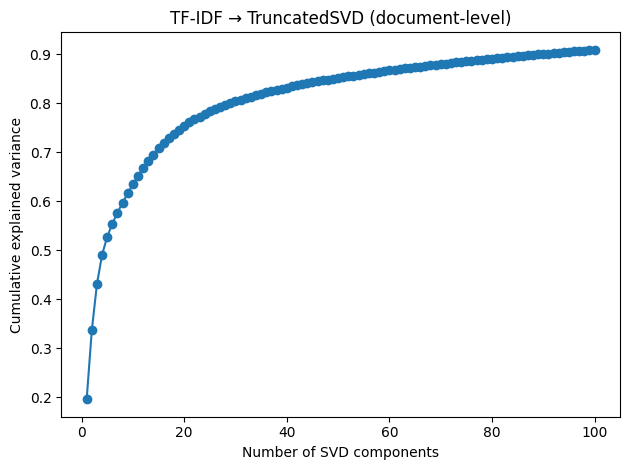

,Doc_ID,tfidf_svd_1,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4,tfidf_svd_5,tfidf_svd_6,tfidf_svd_7,tfidf_svd_8,tfidf_svd_9,...,tfidf_svd_91,tfidf_svd_92,tfidf_svd_93,tfidf_svd_94,tfidf_svd_95,tfidf_svd_96,tfidf_svd_97,tfidf_svd_98,tfidf_svd_99,tfidf_svd_100
0,1,0.073325,-0.086534,0.003073,0.040733,-0.015769,-0.076418,0.090844,0.068580,0.016403,...,0.003142,-0.000134,0.000356,0.000423,0.000150,-0.001310,0.001382,-0.003053,0.000382,-0.000936
1,2,0.088338,-0.078107,-0.000216,0.006903,-0.004942,-0.043004,0.052059,0.021196,0.006927,...,0.003484,0.001822,0.005224,-0.006389,-0.001854,0.005014,0.005485,-0.011138,0.002356,-0.000161
2,3,0.072084,-0.071608,0.000168,-0.002535,-0.009576,-0.032187,0.040147,0.015772,0.002508,...,-0.012980,0.004953,0.003726,0.004968,0.000525,0.007754,0.000531,0.010968,0.005382,0.000794
3,4,0.078889,-0.078055,-0.003011,-0.009228,-0.004302,-0.019116,0.021555,0.000731,0.004952,...,-0.003134,-0.000272,-0.007441,-0.005965,-0.003421,0.001336,0.000599,0.003912,0.000748,0.004635
4,5,0.085778,-0.086746,-0.003945,-0.014549,-0.005634,-0.025627,0.031940,-0.001776,0.015595,...,-0.011420,0.005190,0.004192,-0.001300,-0.013972,-0.000225,-0.004891,0.015135,0.000056,0.005421


In [4]:
# TF-IDF sur phrases
texts = df['Parsed_Text_clean'].fillna('').astype(str).tolist()
n_sent = len(texts)
min_df = 3 if n_sent > 100 else 1
max_df = 0.95 if n_sent > 100 else 1.0

tfidf = TfidfVectorizer(ngram_range=(1,1), min_df=min_df, max_df=max_df)
X_sent = tfidf.fit_transform(texts)

# Agrégation doc (moyenne des phrases par Doc_ID)
doc_codes = df['Doc_ID'].astype('category')
doc_index = doc_codes.cat.codes.values
n_docs = doc_codes.cat.categories.size

row_ids = doc_index
col_ids = np.arange(len(row_ids))
G = sparse.csr_matrix((np.ones_like(col_ids), (row_ids, col_ids)), shape=(n_docs, len(row_ids)))
doc_counts = np.asarray(G.sum(axis=1)).ravel()
X_doc = (G @ X_sent)
doc_counts_safe = np.maximum(doc_counts, 1)[:,None]
X_doc = X_doc.multiply(1.0 / doc_counts_safe)

# SVD (LSA)
svd_k = min(100, max(2, int(min(X_doc.shape) * 0.6))) if min(X_doc.shape) > 2 else 2
svd = TruncatedSVD(n_components=svd_k, random_state=42)
X_doc_svd = svd.fit_transform(X_doc)

# Sauvegarde
tfidf_svd_cols = [f'tfidf_svd_{i+1}' for i in range(X_doc_svd.shape[1])]
df_tfidf_doc = pd.DataFrame(X_doc_svd, columns=tfidf_svd_cols)
df_tfidf_doc.insert(0, 'Doc_ID', doc_codes.cat.categories.values)
df_tfidf_doc.to_csv(OUT_DIR / 'ecb_features_tfidf_svd.csv', index=False)

# Scree plot (variance expliquée cumulée)
plt.figure()
cumvar = np.cumsum(svd.explained_variance_ratio_)
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker='o')
plt.xlabel('Number of SVD components')
plt.ylabel('Cumulative explained variance')
plt.title('TF-IDF → TruncatedSVD (document-level)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'tfidf_svd_scree.png')
plt.show()

df_tfidf_doc.head()

,term,weight
0,monetary,0.316600
1,2022,0.307746
2,policy,0.235903
3,perform,0.190844
4,2023,0.184151
5,price,0.174156
6,record,0.171646
7,dynamic,0.159255
8,outlook,0.150271
9,expect,0.148783


,term,weight
0,avon,0.000022
1,conseil,0.000026
2,gouverneur,0.000026
3,sample,0.000028
4,nom,0.000029
5,premi,0.000031
6,somme,0.000032
7,tre,0.000033
8,dire,0.000034
9,fier,0.000034


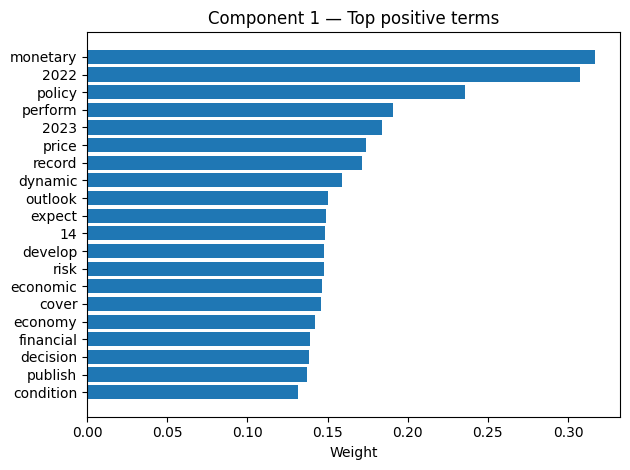

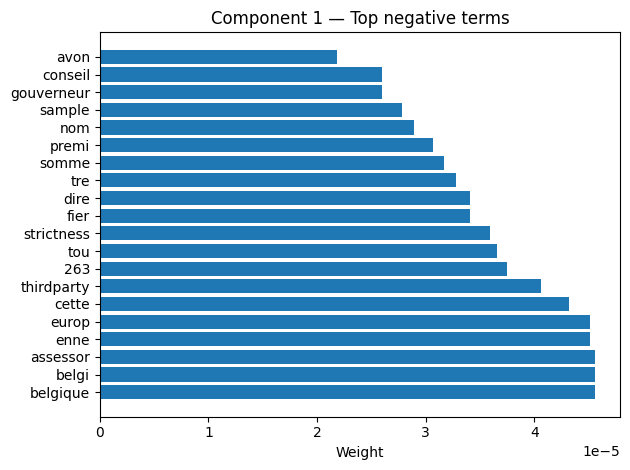

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Récupérer les termes dans le BON ordre (aligné avec X TF-IDF)
try:
    terms = tfidf.get_feature_names_out()  # scikit-learn >= 1.0
except AttributeError:
    # fallback si vieille version: reconstruire un tableau indexé par l'indice exact
    n_features = svd.components_.shape[1]
    terms = np.empty(n_features, dtype=object)
    for term, idx in tfidf.vocabulary_.items():
        if idx < n_features:
            terms[idx] = term

terms = np.asarray(terms)

# 2) Choisir la composante à inspecter
comp = 0  # 0 = tfidf_svd_1, 1 = tfidf_svd_2, etc.
w = svd.components_[comp]  # poids des termes sur cette composante

# Sanity check: alignement dimensions
assert w.shape[0] == len(terms), (
    f"Mismatch: len(terms)={len(terms)} vs w.shape={w.shape}. "
    "Assure-toi que 'svd' a été fit sur la même matrice TF-IDF."
)

# 3) Top positifs et top négatifs
k = 20
top_pos_idx = np.argsort(w)[-k:][::-1]
top_neg_idx = np.argsort(w)[:k]

top_pos = pd.DataFrame({
    "term": terms[top_pos_idx],
    "weight": w[top_pos_idx]
})
top_neg = pd.DataFrame({
    "term": terms[top_neg_idx],
    "weight": w[top_neg_idx]
})

display(top_pos)  # termes qui "tirent" la composante vers le + (thème A)
display(top_neg)  # termes qui "tirent" la composante vers le − (thème B)

# 4) Viz top positifs
plt.figure()
plt.barh(top_pos["term"][::-1], top_pos["weight"][::-1])
plt.xlabel("Weight")
plt.title(f"Component {comp+1} — Top positive terms")
plt.tight_layout()
plt.show()

# 5) Viz top négatifs
plt.figure()
plt.barh(top_neg["term"][::-1], top_neg["weight"][::-1])
plt.xlabel("Weight")
plt.title(f"Component {comp+1} — Top negative terms")
plt.tight_layout()
plt.show()


## FinBERT (optionnel)
Score **pos/neu/neg** par phrase, agrégation **par Doc_ID**, puis `finbert_tone = pos − neg`.  
Histogramme du ton documentaire et export CSVs.

In [6]:
# FinBERT (optionnel)
if USE_FINBERT:
    try:
        from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
        model_name = 'ProsusAI/finbert'
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForSequenceClassification.from_pretrained(model_name)
        pipe = TextClassificationPipeline(model=mdl, tokenizer=tok, return_all_scores=True, truncation=True)
        finbert_ok = True
    except Exception as e:
        print('[WARN] FinBERT non disponible:', e)
        finbert_ok = False
else:
    finbert_ok = False

if finbert_ok:
    fin_text_col = 'Parsed_Text_clean' if FINBERT_ON_CLEAN or 'Parsed_Text' not in df.columns else 'Parsed_Text'
    texts_raw = df[fin_text_col].fillna('').astype(str).tolist()

    scores = []
    B = 64
    for i in range(0, len(texts_raw), B):
        out = pipe(texts_raw[i:i+B])
        scores.extend(out)

    def to_vec(score_list):
        d = {s['label'].lower(): s['score'] for s in score_list}
        return (d.get('positive',0.0), d.get('neutral',0.0), d.get('negative',0.0))

    mat = np.array([to_vec(s) for s in scores], dtype='float64')
    sent_df = pd.DataFrame(mat, columns=['finbert_pos','finbert_neu','finbert_neg'])
    sent_df.insert(0, 'Doc_ID', df['Doc_ID'].values)
    sent_df.insert(1, 'Sentence_Rank', df['Sentence_Rank'].values)
    sent_df.to_csv(OUT_DIR / 'ecb_finbert_sentence_scores.csv', index=False)

    doc_sent = sent_df.groupby('Doc_ID')[['finbert_pos','finbert_neu','finbert_neg']].mean().reset_index()
    doc_sent['finbert_tone'] = doc_sent['finbert_pos'] - doc_sent['finbert_neg']
    doc_sent.to_csv(OUT_DIR / 'ecb_finbert_doc_scores.csv', index=False)

    # Histogramme du ton
    plt.figure()
    plt.hist(doc_sent['finbert_tone'].values, bins=15)
    plt.xlabel('FinBERT tone (pos - neg)')
    plt.ylabel('Count of documents')
    plt.title('Distribution of FinBERT tone (document-level)')
    plt.tight_layout()
    plt.savefig(OUT_DIR/ 'finbert_tone_hist.png')
    plt.show()
else:
    doc_sent = pd.DataFrame({'Doc_ID': df_tfidf_doc['Doc_ID']})

doc_sent.head()

Device set to use cpu
c:\Users\Garance Latieule\analyzing ECB\Analyzing-ECB\.venv\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


: 

: 

## Fusion + MacroTone + Série temporelle
On fusionne TF‑IDF‑SVD avec FinBERT (si dispo) et on calcule **MacroTone_index**.  
On trace la série temporelle si `Date` est disponible.

In [ ]:
# Fusion + MacroTone
feat = df_tfidf_doc.merge(doc_sent, on='Doc_ID', how='left')
if 'tfidf_svd_1' in feat.columns:
    feat['tfidf_svd_1_z'] = zscore(feat['tfidf_svd_1'])

if 'finbert_tone' in feat.columns:
    feat['finbert_tone_z'] = zscore(feat['finbert_tone'].fillna(0.0))
    feat['MacroTone_index'] = feat['tfidf_svd_1_z'].fillna(0.0) + feat['finbert_tone_z'].fillna(0.0)
else:
    feat['MacroTone_index'] = feat.get('tfidf_svd_1_z', pd.Series(0, index=feat.index))

# Attacher Date si dispo (pour plotting)
if 'Date' in df.columns:
    dates = df.drop_duplicates('Doc_ID')[['Doc_ID','Date']]
    feat = feat.merge(dates, on='Doc_ID', how='left')

feat.to_csv(OUT_DIR / 'ecb_features_combined.csv', index=False)
feat.head(10)

,Doc_ID,tfidf_svd_1,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4,tfidf_svd_5,tfidf_svd_6,tfidf_svd_7,tfidf_svd_8,tfidf_svd_9,...,tfidf_svd_99,tfidf_svd_100,finbert_pos,finbert_neu,finbert_neg,finbert_tone,tfidf_svd_1_z,finbert_tone_z,MacroTone_index,Date
0,2,0.011908,0.104226,-0.088289,0.056128,0.057889,-0.043874,-0.008473,-0.023718,0.063308,...,0.028191,0.024029,0.050920,0.896415,0.052664,-0.001744,-0.216060,-0.236970,-0.453030,2025-09-30
1,4,0.002618,0.035435,0.000364,-0.034530,0.008692,0.011852,0.019689,-0.029736,-0.055778,...,0.002788,0.012443,0.058228,0.889418,0.052354,0.005873,-0.303075,-0.127509,-0.430584,2025-09-26
2,5,0.017573,0.050697,0.043671,0.017446,0.024910,0.034085,-0.023595,-0.010403,-0.000989,...,0.012581,0.008841,0.073080,0.759471,0.167449,-0.094369,-0.162997,-1.568029,-1.731025,2025-09-17
3,8,0.001275,0.020935,0.006704,-0.007016,-0.003784,0.003983,0.008115,-0.005152,-0.007834,...,0.012279,0.013187,0.137465,0.777762,0.084772,0.052693,-0.315653,0.545314,0.229661,2025-09-15
4,16,0.002600,0.022213,-0.007458,-0.012953,0.010145,-0.006817,0.018578,-0.014512,-0.022435,...,0.047771,-0.036010,0.148198,0.826345,0.025457,0.122741,-0.303243,1.551932,1.248689,2025-07-10
5,20,0.018110,0.052777,-0.016210,-0.003653,-0.018639,0.001019,0.012456,-0.017857,-0.008197,...,-0.006530,0.006324,0.061383,0.888840,0.049776,0.011607,-0.157969,-0.045114,-0.203084,2025-06-30
6,21,0.009299,0.066137,0.026620,-0.089582,-0.057304,-0.000507,0.024803,-0.010428,0.055871,...,0.038737,-0.023165,0.085366,0.882611,0.032023,0.053344,-0.240497,0.554661,0.314164,2025-06-27
7,22,0.005859,0.039086,-0.007346,-0.019255,0.013132,0.007328,0.013077,0.011074,-0.011832,...,-0.010493,-0.036560,0.091262,0.876415,0.032323,0.058940,-0.272713,0.635076,0.362363,2025-06-26
8,27,0.008370,0.065872,0.005607,-0.036983,0.021891,0.023035,0.014883,-0.061504,-0.048620,...,0.012237,-0.003644,0.051152,0.905756,0.043092,0.008060,-0.249196,-0.096082,-0.345278,2025-06-18
9,32,0.403010,-0.016852,-0.010124,-0.001188,0.001729,0.016311,-0.002809,0.039397,-0.031969,...,-0.028825,0.018648,0.028551,0.935528,0.035921,-0.007371,3.447219,-0.317829,3.129391,2025-06-11


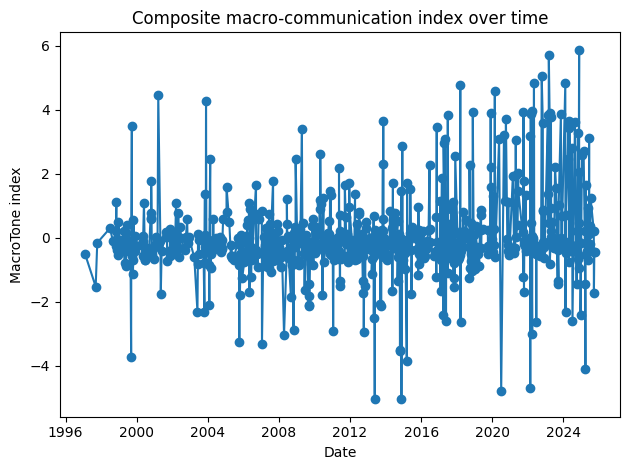

In [ ]:
# Série temporelle MacroTone (si Date existe)
if 'Date' in feat.columns:
    try:
        tmp = feat.drop_duplicates('Doc_ID').copy()
        tmp['Date_parsed'] = pd.to_datetime(tmp['Date'])
        tmp = tmp.sort_values('Date_parsed')
        plt.figure()
        plt.plot(tmp['Date_parsed'], tmp['MacroTone_index'], marker='o')
        plt.xlabel('Date')
        plt.ylabel('MacroTone index')
        plt.title('Composite macro-communication index over time')
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'macrotone_timeseries.png')
        plt.show()
    except Exception as e:
        print('[WARN] Impossible de tracer la série temporelle:', e)